In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

load dataset

In [4]:
import os
if os.path.exists("/content/heart.csv"):
    path = "/content/heart.csv"
else:
    path = "../data/heart.csv"

df = pd.read_csv(path)
df.shape

(1025, 14)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Checking for null values and duplicates

In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df = df.drop_duplicates()
df.shape

(302, 14)

NOw using the cleaned Dataset

In [11]:
df.to_csv("/content/cleaned_dataset.csv", index=False)

In [12]:
df["target"].value_counts()

,count
target,
1,164
0,138


Modeling

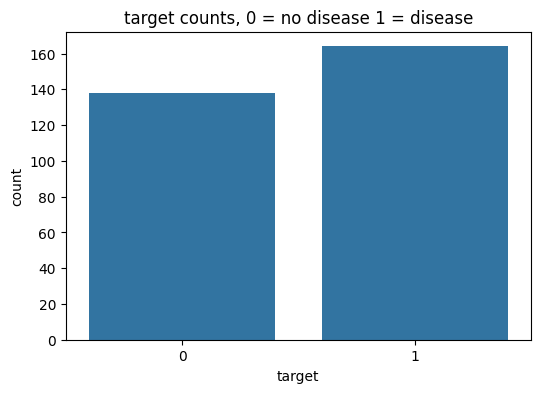

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("target counts, 0 = no disease 1 = disease")
plt.show()

Heatmap

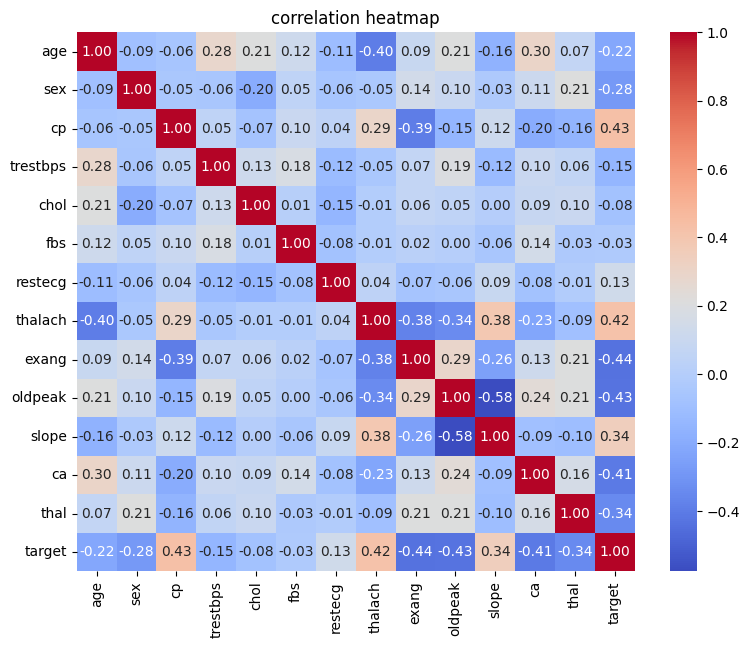

In [14]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

Age vs Target

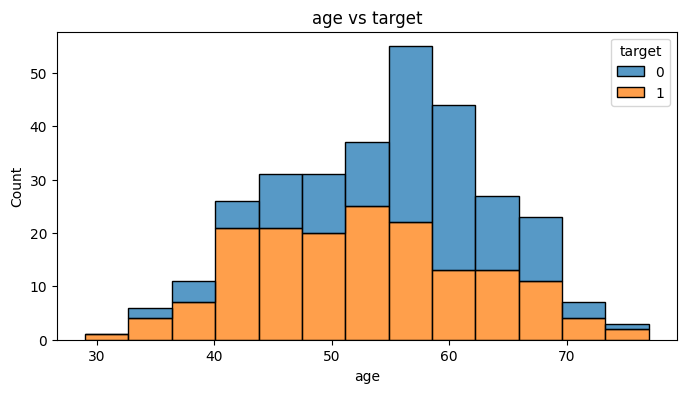

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="age", hue="target", multiple="stack")
plt.title("age vs target")
plt.show()

Split and scale

In [16]:
x = df.drop("target", axis=1)
y = df["target"]

xtr, xte, ytr, yte = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
xtr_sc = sc.fit_transform(xtr)
xte_sc = sc.transform(xte)

xtr.shape, xte.shape

((241, 13), (61, 13))

Train 5 models

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
}

scores = {}
fitted = {}

for name, m in models.items():
    m.fit(xtr_sc, ytr)
    pred = m.predict(xte_sc)
    prob = m.predict_proba(xte_sc)[:, 1]
    scores[name] = {
        "accuracy": accuracy_score(yte, pred),
        "precision": precision_score(yte, pred),
        "recall": recall_score(yte, pred),
        "f1": f1_score(yte, pred),
        "roc_auc": roc_auc_score(yte, prob),
    }
    fitted[name] = m

pd.DataFrame(scores).T

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948
Random Forest,0.754098,0.764706,0.787879,0.776119,0.858766
SVM,0.770492,0.771429,0.818182,0.794118,0.841991
KNN,0.786885,0.777778,0.848485,0.811594,0.837662


COmparing them

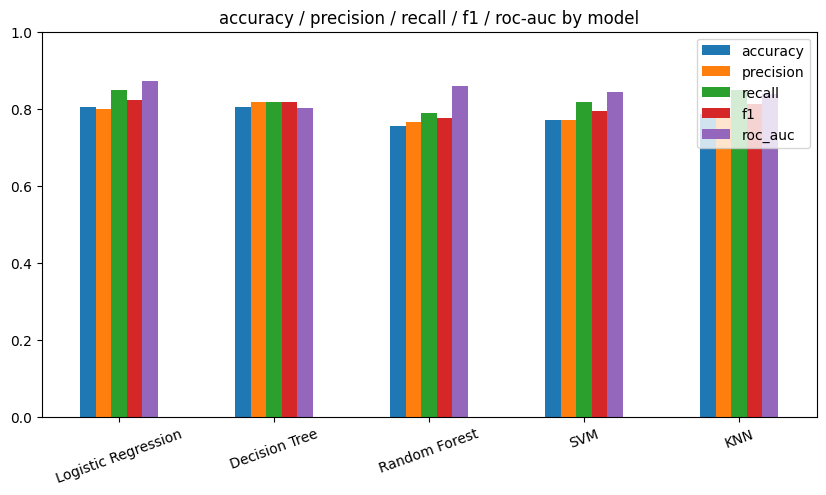

In [18]:
pd.DataFrame(scores).T.plot(kind="bar", figsize=(10,5))
plt.title("accuracy / precision / recall / f1 / roc-auc by model")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

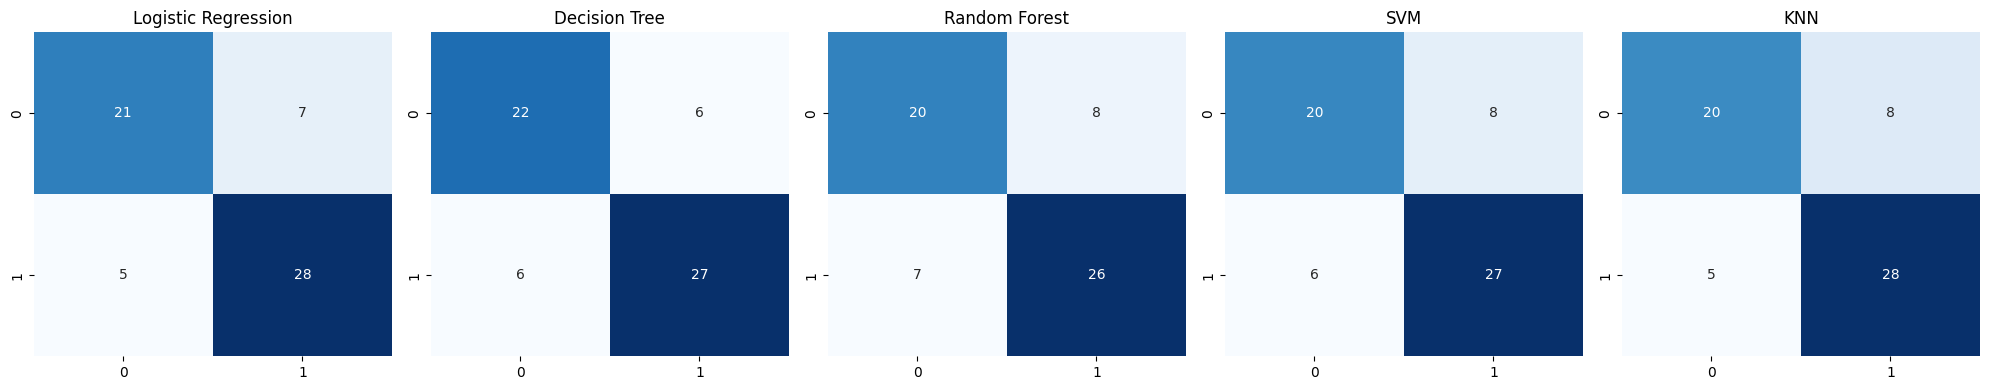

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, name in zip(axes, fitted):
    pred = fitted[name].predict(xte_sc)
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [20]:
best_name = max(scores, key=lambda n: scores[n]["accuracy"])
best_name

'Logistic Regression'

Using Log Regression

In [21]:
if best_name == "SVM":
    params = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1, 1]}
    base = SVC(probability=True, random_state=42)
elif best_name == "Random Forest":
    params = {"n_estimators": [100,200,300], "max_depth": [None,5,10,15], "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,4]}
    base = RandomForestClassifier(random_state=42)
elif best_name == "Decision Tree":
    params = {"max_depth": [None,3,5,8,10], "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,4], "criterion": ["gini","entropy"]}
    base = DecisionTreeClassifier(random_state=42)
elif best_name == "Logistic Regression":
    params = {"C": [0.01,0.1,1,10,100]}
    base = LogisticRegression(max_iter=1000)
else:
    params = {"n_neighbors": [3,5,7,9,11]}
    base = KNeighborsClassifier()

grid = GridSearchCV(base, params, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(xtr_sc, ytr)
grid.best_params_

{'C': 0.01}

In [22]:
tuned = grid.best_estimator_
pred = tuned.predict(xte_sc)
prob = tuned.predict_proba(xte_sc)[:, 1]

tuned_score = {
    "accuracy": accuracy_score(yte, pred),
    "precision": precision_score(yte, pred),
    "recall": recall_score(yte, pred),
    "f1": f1_score(yte, pred),
    "roc_auc": roc_auc_score(yte, prob),
}
scores[best_name + " (Tuned)"] = tuned_score
tuned_score

{'accuracy': 0.8032786885245902,
 'precision': 0.7837837837837838,
 'recall': 0.8787878787878788,
 'f1': 0.8285714285714286,
 'roc_auc': np.float64(0.880952380952381)}

Before vs After

In [23]:
pd.DataFrame({"before": scores[best_name], "after": tuned_score})

,before,after
accuracy,0.803279,0.803279
precision,0.800000,0.783784
recall,0.848485,0.878788
f1,0.823529,0.828571
roc_auc,0.871212,0.880952


Feature importance

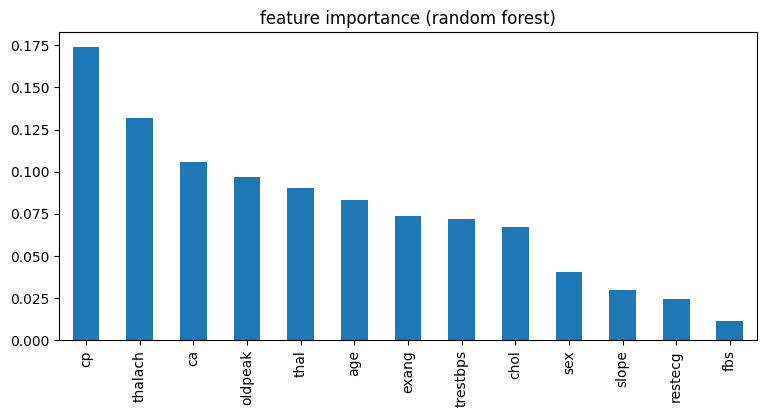

In [24]:
rf_importance = fitted["Random Forest"].feature_importances_
imp = pd.Series(rf_importance, index=x.columns).sort_values(ascending=False)
imp.plot(kind="bar", figsize=(9,4))
plt.title("feature importance (random forest)")
plt.show()

Save model

In [25]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(tuned, "../models/best_model.pkl")
joblib.dump(sc, "../models/scaler.pkl")
joblib.dump(list(x.columns), "../models/columns.pkl")
joblib.dump(scores, "../models/scores.pkl")
joblib.dump(dict(zip(x.columns, rf_importance)), "../models/feature_importance.pkl")
joblib.dump(best_name, "../models/best_name.pkl")

print("done")

done
